# 03. Model Baselines & Selection

This notebook executes a competitive "model bake-off" to establish performance baselines. It compares linear archetypes (Lasso, Ridge, SVR) against non-linear ensemble methods (RandomForest, XGBoost) to determine if the alpha signal requires non-linear feature interaction or if a simpler linear approximation suffices.

**Key Technical Steps:**
1.  **Data Loading:** Imports the processed feature set and enforces the temporal split (validation on data $\ge$ 2023).
2.  **Baseline Competition:** Runs a 5-fold cross-validation on a diverse suite of regressors (BayesianRidge, LassoCV, LinearSVR, RandomForest, XGBoost).
3.  **Performance Evaluation:** Visualizes R² distributions to identify models that statistically beat the naive mean.

In [3]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import sys
import os

# Add project root to path
sys.path.append(os.path.abspath('..'))

from src.utils.logger import setup_logger
from src.models.baselines import run_model_bakeoff
from src.utils.visualizations import plot_model_performance

logger = setup_logger("03_model_selection")

# Load Processed Data
data_path = "../data/processed/final_model_data.parquet"
if os.path.exists(data_path):
    df = pd.read_parquet(data_path)
    logger.info(f"Data Loaded. Shape: {df.shape}")
else:
    logger.error("Data file not found. Run Notebook 02 first.")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
2026-03-07 07:11:32,466 - INFO - Data Loaded. Shape: (93829, 94)


#### **Temporal Splitting & Target Isolation**

Quantitative finance models require strict temporal separation to prevent look-ahead bias. Here, we isolate the validation period (post-2023) to evaluate our baselines. We also separate the feature matrix ($X$) from the forward return target ($y$) and perform a final sanity check for missing values.

**Key Actions:**
* **Temporal Slice:** Subsets data where `date >= '2023-01-01'`.
* **Target Separation:** Isolates `FwdRet` as the prediction target.
* **Sanity Check:** Drops any remaining NaNs to ensure `sklearn` compatibility.

In [5]:
gdf = df.loc[df.index.get_level_values(0) >= pd.Timestamp('2023-01-01')].copy()

target_col = 'FwdRet'

# Explicitly select features (matching consolidated notebook §2.1 cell 82)
# Exclude target columns and any non-feature columns
exclude_cols = [target_col, 'FwdRetOrig']
feature_cols = [c for c in gdf.columns if c not in exclude_cols]

X_full = gdf[feature_cols].copy()
y_full = gdf[target_col].copy()

print("X_full shape:", X_full.shape)
print("y_full shape:", y_full.shape)

# Clean any remaining NaNs just in case
mask = X_full.notna().all(axis=1) & y_full.notna()
X = X_full.loc[mask].copy()
y = y_full.loc[mask].copy()

print("\nAfter NaN cleaning:")
print("X shape:", X.shape)
print("y shape:", y.shape)

X_full shape: (8971, 92)
y_full shape: (8971,)

After NaN cleaning:
X shape: (8971, 92)
y shape: (8971,)


#### **Baseline Model Sweep ("The Bake-off")**

We execute a 5-fold Cross-Validation loop across distinct model archetypes: linear (Lasso, Ridge, SVR) and non-linear (RandomForest, XGBoost). This "bake-off" determines if the alpha signal is linear or requires tree-based interactions.

**Key Actions:**
* **Archetype Comparison:** Tests `BayesianRidge` (Linear Baseline) vs `RandomForest/XGBoost` (Non-linear).
* **Cross-Validation:** Uses `KFold(n_splits=5, shuffle=True)` to generate robust error metrics.
* **Metric:** Optimizes for $R^2$ (Coefficient of Determination).

In [6]:
# Run CV and get the scoreboard
# This runs the logic from src/models/baselines.py
results_df = run_model_bakeoff(X, y, n_splits=5)

display(results_df)

2026-03-07 07:20:03,274 - INFO - Starting Model Bake-off with 5 models and 5 CV splits...
2026-03-07 07:20:03,281 - INFO - Training BayesianRidge...
2026-03-07 07:20:08,673 - INFO -    -> BayesianRidge R2: 0.0347
2026-03-07 07:20:08,682 - INFO - Training LassoCV...
2026-03-07 07:20:10,663 - INFO -    -> LassoCV R2: -0.0009
2026-03-07 07:20:10,663 - INFO - Training LinearSVR...


/Users/aengusmartindonaire/.conda/envs/hedging_clean/lib/python3.10/site-packages/sklearn/svm/_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/Users/aengusmartindonaire/.conda/envs/hedging_clean/lib/python3.10/site-packages/sklearn/svm/_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/Users/aengusmartindonaire/.conda/envs/hedging_clean/lib/python3.10/site-packages/sklearn/svm/_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/Users/aengusmartindonaire/.conda/envs/hedging_clean/lib/python3.10/site-packages/sklearn/svm/_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


2026-03-07 07:20:13,156 - INFO -    -> LinearSVR R2: 0.0156
2026-03-07 07:20:13,158 - INFO - Training RandomForest...


/Users/aengusmartindonaire/.conda/envs/hedging_clean/lib/python3.10/site-packages/sklearn/svm/_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


2026-03-07 07:20:19,003 - INFO -    -> RandomForest R2: 0.0589
2026-03-07 07:20:19,007 - INFO - Training XGBoost...
2026-03-07 07:20:19,515 - INFO -    -> XGBoost R2: 0.0470


,Model,R2 Mean,R2 Std
3,RandomForest,0.058916,0.017025
4,XGBoost,0.047045,0.007439
0,BayesianRidge,0.034695,0.009275
2,LinearSVR,0.015626,0.008755
1,LassoCV,-0.000855,0.000530


#### **Performance Visualization**

Visualizing the spread of $R^2$ scores across CV folds is crucial for assessing model stability. A model with a slightly lower mean but lower variance is often preferred in finance over a volatile high-performer.

/Users/aengusmartindonaire/Downloads/Projects/systematic-equity-alpha/src/utils/visualizations.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


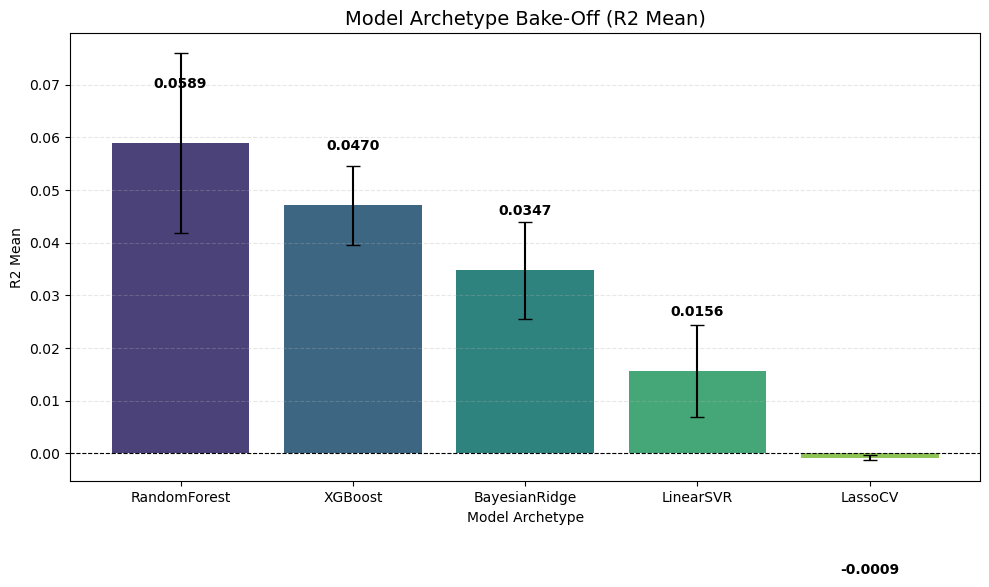

In [7]:
# Visualize results
plot_model_performance(results_df, metric='R2 Mean', std_col='R2 Std')

* `LassoCV` and `LinearSVR` have R² that are essentially or significantly closer to zero than the other three models, so they are effectively not beating the naive mean. That tells us the linear/SVR archetype is not suited to this problem, so we eliminate them.
* `BayesianRidge`, `RandomForest`, and `XGBoost` are clearly above zero, so these are our finalists.”
* `RandomForest` beating XGBoost, given we crippled XGBoost with a tiny learning rate and only 100 estimators, is a suspicious result. It is a sign that `XGBoost` is underfitting and needs a proper tuning.

In [8]:
import os

# 1. Create a 'results' directory if it doesn't exist
results_dir = "../results"
os.makedirs(results_dir, exist_ok=True)

# 2. Save the Bake-off Scoreboard
# This is useful for your final report/README
results_df.to_csv(os.path.join(results_dir, "03_model_bakeoff_metrics.csv"), index=False)

print(f"✅ Scoreboard saved to {results_dir}/03_model_bakeoff_metrics.csv")
print("✅ You do not need to save the data (X, y); Notebook 04 will reload 'final_model_data.parquet'.")

✅ Scoreboard saved to ../results/03_model_bakeoff_metrics.csv
✅ You do not need to save the data (X, y); Notebook 04 will reload 'final_model_data.parquet'.


In [ ]:
# ============================================================== EOF ========================================================================